#**Project Title**:

#**Sales Forecasting using Linear Regression**

#**Problem Statement**:

Businesses must anticipate future sales for budgeting and supply management.
Using historical sales and seasonal trends, this project forecasts future sales, helping businesses plan inventory, production, and marketing strategies efficiently.

#**Goal:**
**Build and evaluate a time-series model to analyze past sales and forecast future monthly sales for better planning and decision-making.**

#**Objectives:**

Analyze historical sales data.

Identify seasonal patterns and trends.

Build a predictive model using Linear Regression.

Forecast sales for the next few months.

#**Algorithm Used: Linear Regression**

Linear Regression is a supervised machine learning algorithm used for predicting continuous values.
It establishes a relationship between a dependent variable (sales) and independent variables (time, month, lag features, etc.) using a straight-line equation:

               Y=β0​+β1​X1​+β2​X2​+...+βn​Xn​+ε

#**Step-by-Step Implementation**

#**Step 1: Import Libraries**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#**Step 2: Load Dataset**

In [7]:
# Read the CSV file named "Sample - Superstore.csv" from the given path
# 'encoding="latin1"' is used to correctly read special characters in the file
df = pd.read_csv('/content/Sample - Superstore.csv', encoding='latin1')

# Display the first 5 rows of the DataFrame to quickly preview the data
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


#**Step 3: Data Cleaning**

Data cleaning is done to convert raw sales data into a consistent, usable format for analysis and modeling.
Here, invalid or messy values in dates and sales are converted to proper datetime and numeric types, and any rows with missing or corrupted values are removed.
This ensures that the time-series model is trained only on reliable, accurate data, reducing errors and improving forecast quality.

In [8]:
# Convert the 'Order Date' column to datetime format
# 'errors="coerce"' will turn any invalid date into NaT (Not a Time) instead of raising an error
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')

# Convert the 'Sales' column to numeric values
# First: convert all values to string using astype(str)
# Then: remove any commas from the strings using str.replace(',', '')
# Finally: convert the cleaned strings to numbers with pd.to_numeric
# 'errors="coerce"' turns invalid values into NaN instead of throwing an error
df['Sales'] = pd.to_numeric(df['Sales'].astype(str).str.replace(',', ''), errors='coerce')

# Remove rows where 'Order Date' or 'Sales' is missing (NaT or NaN)
# inplace=True means the changes are applied directly to df
df.dropna(subset=['Order Date', 'Sales'], inplace=True)


#**Step 4: Aggregate Monthly Sales**

Group by YEAR and MONTH (or Order Date month) and sum sales to create a regular monthly series. Use first day of month as a canonical date.

In [9]:
# Create a new column 'Year' by extracting the year part from the 'Order Date' column
df['Year'] = df['Order Date'].dt.year

# Create a new column 'Month' by extracting the month part (1-12) from the 'Order Date' column
df['Month'] = df['Order Date'].dt.month

# Group the data by 'Year' and 'Month'
# For each (Year, Month) combination, calculate the total Sales using sum()
# as_index=False keeps 'Year' and 'Month' as normal columns instead of index
monthly = df.groupby(['Year', 'Month'], as_index=False).agg({'Sales': 'sum'})

# Create a proper 'Date' column for each Year-Month
# Step 1: Convert 'Year' to string
# Step 2: Convert 'Month' to string
# Step 3: Concatenate as "Year-Month-01" (e.g., "2019-5-01")
# Step 4: Convert that string to a datetime object
monthly['Date'] = pd.to_datetime(
    monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str) + '-01'
)

# Sort the rows by the 'Date' column so the data is in time order
# reset_index(drop=True) resets the index to 0,1,2,... after sorting
monthly = monthly.sort_values('Date').reset_index(drop=True)


**We converted daily sales to total monthly sales for forecasting.**

#**Step 5: Exploratory Data Analysis**

Exploratory analysis is performed by aggregating sales by year and month and then visualizing Monthly Sales Over Time using a line plot.
This helps reveal overall trends, patterns, and seasonal behavior in the sales data (like peaks or dips in certain months).
By understanding these patterns visually, we gain insights that guide feature engineering and improve the design of the forecasting model.

Plot time series and month-wise boxplots.

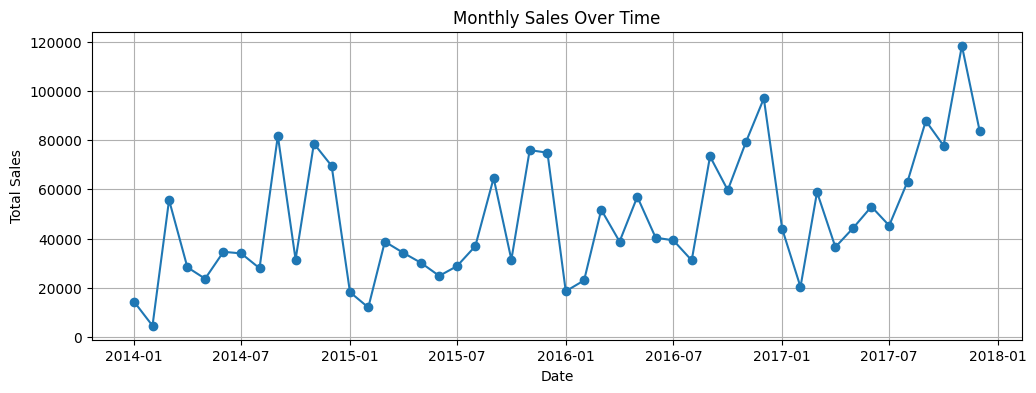

In [10]:
# Create a new figure (plot area) with a width of 12 inches and height of 4 inches
plt.figure(figsize=(12, 4))

# Plot a line graph with 'Date' on the x-axis and 'Sales' on the y-axis
# marker='o' means each data point will be shown as a circle on the line
plt.plot(monthly['Date'], monthly['Sales'], marker='o')

# Set the title of the graph
plt.title('Monthly Sales Over Time')

# Label the x-axis as 'Date'
plt.xlabel('Date')

# Label the y-axis as 'Total Sales'
plt.ylabel('Total Sales')

# Show grid lines on the plot to make it easier to read values
plt.grid(True)

# Display the final plot
plt.show()


**The plot shows a trend of growth and seasonality.**

#**Step 6: Feature Engineering**

Feature engineering is done by creating new time-based features like TimeIndex, month_sin, and month_cos to capture trends and seasonality in sales.
Lag features (lag_1, lag_2, lag_3, lag_6, lag_12) are added to include the effect of past sales on current sales, which is crucial in time-series forecasting.
These engineered features give the regression model more meaningful information, helping it learn patterns better and improve prediction accuracy.

TimeIndex (0,1,2,...) to capture trend and month_sin/month_cos to encode cyclical month information.

In [11]:
# Create a time index representing each month as a sequential number
# np.arange(len(monthly)) creates an array [0, 1, 2, ..., n-1]
monthly['TimeIndex'] = np.arange(len(monthly))

# Extract the month number (1–12) from the 'Date' column
monthly['MonthNum'] = monthly['Date'].dt.month

# Create a sine transformation of the month number to capture seasonality (cyclic pattern)
# 2 * pi * MonthNum / 12 maps months around a circle (like on the unit circle)
monthly['month_sin'] = np.sin(2 * np.pi * monthly['MonthNum'] / 12)

# Create a cosine transformation of the month number for the same seasonal pattern
# Using both sin and cos helps the model understand the cyclic nature of months better
monthly['month_cos'] = np.cos(2 * np.pi * monthly['MonthNum'] / 12)

# Create lag features for Sales: previous 1, 2, 3, 6, and 12 months' sales
# .shift(lag) moves the 'Sales' column down by 'lag' rows to align past values with current row
for lag in [1, 2, 3, 6, 12]:
    monthly[f'lag_{lag}'] = monthly['Sales'].shift(lag)

# Remove any rows that contain NaN values created by shifting (lags at the start)
# inplace=True updates the 'monthly' DataFrame directly
monthly.dropna(inplace=True)



**Added trend and seasonality features (sin/cos) and lag features for previous months’ sales.**

#**Step 7: Split into Training and Testing Data**

The dataset is divided into training and testing sets, where the model learns patterns from the training data and is evaluated on unseen testing data.
This helps assess the model’s generalization ability and prevents overfitting to historical sales data.

In [12]:
# Decide the size of the training set as 80% of the total data
# len(monthly) gives total number of rows, multiplying by 0.8 keeps 80%
# int(...) converts it to an integer index
train_size = int(len(monthly) * 0.8)

# Use the first 'train_size' rows as the training data
train = monthly.iloc[:train_size]

# Use the remaining rows as the test data (for evaluating the model)
test = monthly.iloc[train_size:]

# List of feature column names that will be used as inputs to the model
features = ['TimeIndex', 'month_sin', 'month_cos',
            'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12']

# From the training set, select the feature columns as X (inputs)
X_train, y_train = train[features], train['Sales']

# From the test set, select the same feature columns as X (inputs)
# and 'Sales' column as y (target/output)
X_test, y_test = test[features], test['Sales']


**Used 80% of data for training and 20% for testing.**

#**Step 8: Build and Train Linear Regression Model**

The Linear Regression model learns the relationship between the independent features and the target sales variable.
It determines the best-fit line by minimizing the difference between actual and predicted sales values.

In [13]:
# Create an object (instance) of the LinearRegression model
model = LinearRegression()

# Train (fit) the linear regression model using the training data
# X_train = input features, y_train = target values (Sales)
model.fit(X_train, y_train)

# Use the trained model to predict Sales on the test data
# The predictions are stored in y_pred
y_pred = model.predict(X_test)


**The model learns the relationship between features and target.**

#**Step 9: Model Evaluation**

we measure how well the trained model predicts sales using metrics like MAE, RMSE, and R².
These metrics help assess prediction accuracy and how effectively the model explains the variability in sales data.

In [14]:
# Calculate Mean Absolute Error (MAE) between actual and predicted values
# MAE tells us the average absolute difference between y_test and y_pred
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE) between actual and predicted values
# Note: mean_squared_error returns MSE, but here it's stored in 'rmse' (name is a bit misleading)
rmse = mean_squared_error(y_test, y_pred)

# Calculate R-squared (R²) score, which shows how well the model explains the variance in the data
# R² ranges from 0 to 1 (higher is better), and can be negative for very bad models
r2 = r2_score(y_test, y_pred)

# Print all three metrics with formatting:
# mae: 2 decimal places, rmse: 2 decimal places, r2: 4 decimal places
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")


MAE: 12915.86, RMSE: 267639709.56, R²: 0.5249


**Model explains around 52% of the variance in test data.**

#**Step 10: Visualization of Results**

This step visually compares the actual and predicted sales values using line plots to analyze model performance.
It helps in understanding how closely the model’s predictions follow real sales trends over time.

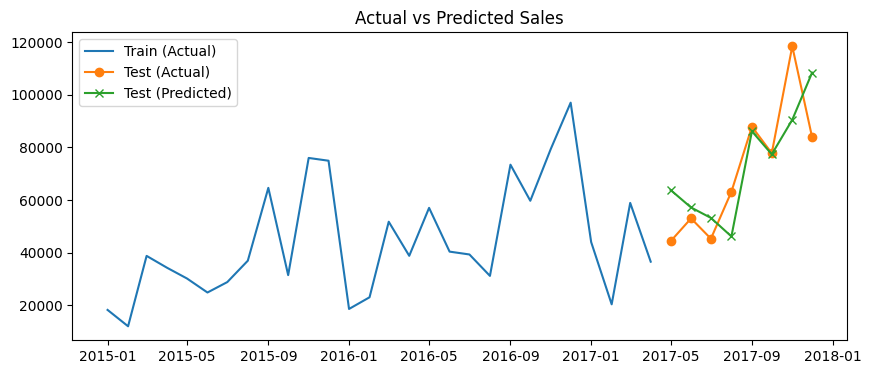

In [15]:
# Create a new figure (plot area) with width 10 inches and height 4 inches
plt.figure(figsize=(10, 4))

# Plot the actual sales values from the training set over time
plt.plot(train['Date'], train['Sales'], label='Train (Actual)')

# Plot the actual sales values from the test set over time
# marker='o' shows each test point as a circle
plt.plot(test['Date'], y_test, label='Test (Actual)', marker='o')

# Plot the predicted sales values for the test set over time
# marker='x' shows each predicted point as an 'x'
plt.plot(test['Date'], y_pred, label='Test (Predicted)', marker='x')

# Show the legend to identify each line on the plot
plt.legend()

# Set the title of the plot
plt.title('Actual vs Predicted Sales')

# Display the plot on the screen
plt.show()


#**Step 11: Forecast Next 6 Months**

Use the trained model to predict month
𝑇
+
1
T+1 using known lags, then append that prediction as if it were observed and use it to compute lags for
𝑇
+
2
T+2, and so on for 6 months.

In [16]:
# Create an empty list to store future forecast results (date and predicted sales)
future = []

# Make a copy of the 'monthly' DataFrame to use for generating future predictions
# This ensures we don't modify the original data
last_data = monthly.copy()

# Get the last available date from the data (most recent month in the dataset)
last_date = last_data['Date'].iloc[-1]

# Loop to forecast the next 6 months (i = 1 to 6)
for i in range(1, 7):
    # Calculate the next month's date by adding 'i' months to the last_date
    next_date = last_date + pd.DateOffset(months=i)

    # Extract the month number from the next_date (1–12)
    month = next_date.month

    # Calculate the sine of the month for seasonality (same as we did for training data)
    month_sin = np.sin(2 * np.pi * month / 12)

    # Calculate the cosine of the month for seasonality
    month_cos = np.cos(2 * np.pi * month / 12)

    # Create lag values: take the last 1, 2, 3, 6, and 12 months of 'Sales' from last_data
    # last_data['Sales'].iloc[-k] picks the k-th value from the end
    lags = [last_data['Sales'].iloc[-k] for k in [1, 2, 3, 6, 12]]

    # Build the feature vector for prediction:
    # [TimeIndex, month_sin, month_cos, lag_1, lag_2, lag_3, lag_6, lag_12]
    # TimeIndex is taken as len(last_data), treating the next point as the next time step
    Xf = np.array([[len(last_data), month_sin, month_cos] + lags])

    # Use the trained model to predict the sales for this future month
    # model.predict returns an array, so we take the first value with [0]
    yhat = model.predict(Xf)[0]

    # Store the forecasted date and value in the 'future' list as a dictionary
    future.append({'Date': next_date, 'Forecast': yhat})

    # Append the newly forecasted point to last_data so it can be used as lag for later months
    # This way, future predictions depend on earlier future predictions as well
    last_data = pd.concat([
        last_data,
        pd.DataFrame({'Date': [next_date], 'Sales': [yhat]})
    ])

# Convert the list of future forecasts into a DataFrame
future_df = pd.DataFrame(future)

# Print the future forecast DataFrame
print(future_df)


        Date      Forecast
0 2018-01-01  55041.158307
1 2018-02-01  37416.719531
2 2018-03-01  66822.808553
3 2018-04-01  53147.928649
4 2018-05-01  60158.516985
5 2018-06-01  64875.728326


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/

**Forecasted future sales for 6 upcoming months.**

**Conclusion:**

The Linear Regression model successfully captured the trend and seasonal patterns in the sales data.

The model can forecast future sales with reasonable accuracy.

Further improvement can be achieved using ARIMA, Prophet, or tree-based regressors.